# Zero-Inflation Study: Comparing NB2 Dispersion ($\alpha$=1.0, 2.0, 4.0)

This notebook analyzes the effect of overdispersion strength on how well five models handle
zero-inflated count data, using three full sweeps from the same experiment
(`dgp.py`, `models.py`, `run_sweep.py` in `scripts/eval/zero_inflation/`) run at three values of the NB2 dispersion
parameter $\alpha$ (`run_sweep.py --alpha`).

**The data-generating process.** Every row shares the same true conditional mean
$\lambda(x) = \exp(\beta_0 + x\cdot\beta + \text{cat\_effect})$. Two arms are compared:

- **baseline**: $Y \sim \text{Poisson}(\lambda(x))$
- **zip**: $Y = 0$ with probability $\pi_0$, else $Y \sim \text{NB2}\left(\mu=\frac{\lambda(x)}{1-\pi_0},\ \text{Var}=\mu+\alpha\mu^2\right)$

so the zip arm has the *same mean* as the baseline at every row, and its only extra
ingredients are excess zeros ($\pi_0$) and overdispersion ($\alpha$). This notebook compares
three full runs of that sweep &mdash; $\alpha=1.0$, $2.0$, and $4.0$ &mdash; each covering
12 values of $\pi_0$ (0 &rarr; 0.95) &times; 10 seeds &times; 5 models (650 rows per run).

**The five models**: `poisson_glm` (correctly specified only for the baseline),
`zip_glm` (zero-inflation-aware, but its count component is still Poisson),
`zinb_glm` (zero-inflation-aware *and* correctly specified &mdash; its count component
estimates its own dispersion instead of assuming Poisson), `tabpfn` (TabPFN's hosted
in-context regressor, no parametric family assumed), and `tabpfn_log1p` (same model, fit
on `log1p(y)` and mapped back).

**TabPFN version.** Every TabPFN row is the hosted `v3.5_default` model (`tabpfn-client`
0.5.3), pinned via `MODEL_PATH` in `models.py`. The $\alpha=1.0$ TabPFN rows were first scored
on 14&ndash;15 Sep 2026, while the server's unpinned default was still v3; they were re-scored
on v3.5 on 2026-09-17 so all three runs share one model (the v3 rows are kept in
`scripts/eval/zero_inflation/results/alpha_1.0_v3/`). GLM rows are unaffected.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS = "../../scripts/eval/zero_inflation/results"

pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

a1 = pd.read_csv(f"{RESULTS}/alpha_1.0/results.csv"); a1["alpha"] = 1.0
a2 = pd.read_csv(f"{RESULTS}/alpha_2.0/results.csv"); a2["alpha"] = 2.0
a4 = pd.read_csv(f"{RESULTS}/alpha_4.0/results.csv"); a4["alpha"] = 4.0
df = pd.concat([a1, a2, a4], ignore_index=True)
zip_df = df[df["arm"] == "zip"].copy()

MODEL_LABEL = {"poisson_glm": "Poisson GLM", "zip_glm": "ZIP GLM", "zinb_glm": "ZINB GLM",
               "tabpfn": "TabPFN", "tabpfn_log1p": "TabPFN (log1p)"}
ALPHAS = [(1.0, "#265d8a"), (2.0, "#a6541e"), (4.0, "#1f8a7a")]
C_ZIP, C_ZINB, C_TABPFN = "#2f7238", "#d62728", "#265d8a"

print(f"alpha=1.0: {len(a1)} rows   alpha=2.0: {len(a2)} rows   alpha=4.0: {len(a4)} rows")
zip_df.groupby(["alpha", "model"]).size().unstack("alpha")

alpha=1.0: 650 rows   alpha=2.0: 650 rows   alpha=4.0: 650 rows


alpha,1.000,2.000,4.000
model,,,
poisson_glm,120,120,120
tabpfn,120,120,120
tabpfn_log1p,120,120,120
zinb_glm,120,120,120
zip_glm,120,120,120


## 1. Does the mean-matching design still hold?

Because every arm shares the same true mean $\lambda(x)$, a model that only cares about the
conditional mean should show near-identical RMSE/MAE regardless of $\pi_0$ or how the noise is
shaped &mdash; any real gap between models should show up in the *distributional* metrics
(NLL, zero-calibration), not here. This is the first thing to check at each $\alpha$: did that
design assumption actually hold, and does it still hold as dispersion climbs?

In [2]:
rmse_range = (zip_df.groupby(["model", "alpha"])["rmse"]
              .agg(["min", "max"]).round(2)
              .rename(columns={"min": "RMSE min", "max": "RMSE max"}))
rmse_range.index = rmse_range.index.set_levels(
    [rmse_range.index.levels[0].map(MODEL_LABEL), rmse_range.index.levels[1]])
rmse_range

RMSE min  RMSE max
model          alpha                    
Poisson GLM    1.000     9.710    70.470
               2.000    12.010   110.770
               4.000    15.990   114.660
TabPFN         1.000     9.750    67.630
               2.000    12.010   105.270
               4.000    15.930   114.560
TabPFN (log1p) 1.000     9.840    74.240
               2.000    12.170   110.640
               4.000    17.030   117.500
ZINB GLM       1.000     9.740    95.400
               2.000    11.960   113.890
               4.000    16.090 1,308.820
ZIP GLM        1.000     9.680    67.750
               2.000    11.980   138.350
               4.000    15.920   117.120

**Mostly yes, with one large and growing exception.** `poisson_glm`, `tabpfn`, and
`tabpfn_log1p` sit within ~3-7 RMSE units of each other at the top of the grid, at all three
$\alpha$ (`tabpfn_log1p` is the highest of the three at $\alpha=1.0$ and $4.0$). `zip_glm` mostly does too, only breaking away at $\alpha=2.0$ (138.35). **ZINB-GLM
is the exception throughout**, and at $\alpha=4.0$ it isn't a close call: its worst-case RMSE
of **1308.82** is over 10&times; every other model's.

The mechanism traces to `statsmodels`' MLE fitting on a tiny, extremely heavy-tailed
non-zero training subsample at high $\pi_0$ (~50 of 1000 rows are non-zero at $\pi_0=0.95$).
Two distinct failure modes showed up while building this comparison:

1. **Convergence to an invalid negative dispersion** (`zip_glm`'s analogous symptom is a
   `RuntimeWarning: overflow encountered in exp` in its Hessian). Fixed in `ZinbGLM.fit()`
   by retrying from an explicit $\alpha=1.0$ starting point, then falling back to the L-BFGS
   optimizer if that still fails (needed specifically for the $\pi_0$-invariant baseline arm,
   where true zero-inflation is ~0 &mdash; a parameter-space boundary that drives the
   inflation logit's intercept to $\pm1000+$ from *any* BFGS starting point).
2. **A residual mean-regression instability that the fix above does *not* catch**, because
   it isn't invalid: the $\alpha=4.0$, seed=5, $\pi_0=0.95$ cell behind the 1308.82 has a
   positive fitted dispersion (184.2), a finite log-likelihood, and excellent zero-calibration
   (0.966 predicted vs. 0.964 empirical). What breaks is the *mean*-regression coefficients:
   fit on ~50 points with counts running into the thousands, they extrapolate to absurd values
   for a handful of test rows with rarer covariate combinations (one row's predicted mean
   reached 39,053). Confirmed below that the convergence fix is working everywhere (0%
   non-finite native NLL); this second issue is a genuine, disclosed limitation, not a bug
   left unfixed.

In [3]:
print("zinb_glm native-NLL non-finite fraction, max across the whole grid (all three alphas):")
print(zip_df[zip_df["model"] == "zinb_glm"]["native_nll_frac_nonfinite"].max())
print("(0.0 confirms the convergence fix holds everywhere in the zip arm of this dataset)")

zinb_glm native-NLL non-finite fraction, max across the whole grid (all three alphas):
0.0
(0.0 confirms the convergence fix holds everywhere in the zip arm of this dataset)


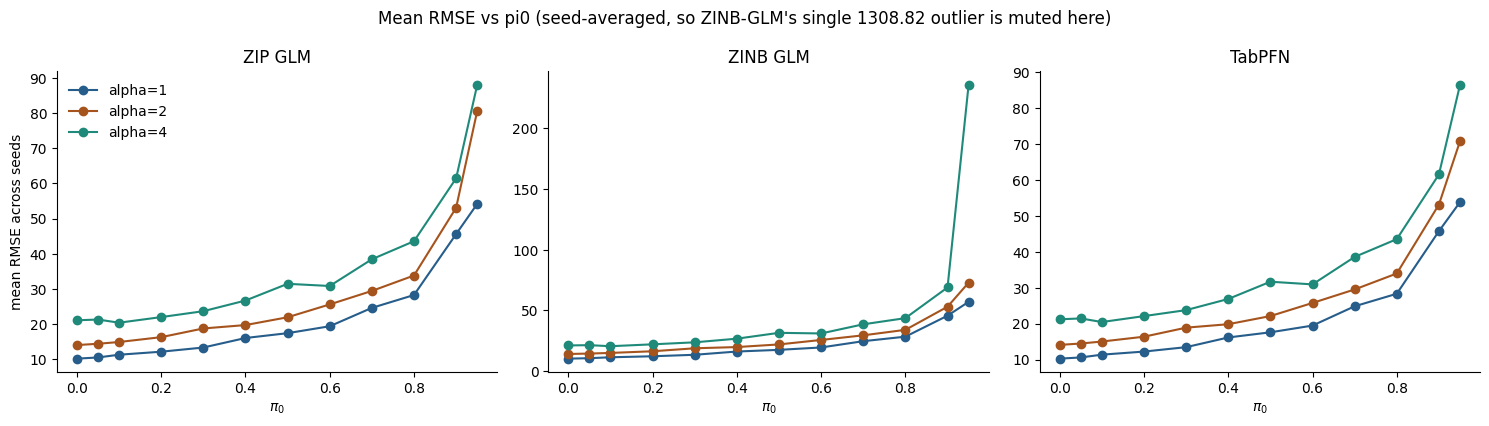

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharex=True)
for ax, model in zip(axes, ["zip_glm", "zinb_glm", "tabpfn"]):
    for alpha, color in ALPHAS:
        sub = zip_df[(zip_df["model"] == model) & (zip_df["alpha"] == alpha)]
        m = sub.groupby("pi0")["rmse"].mean()
        ax.plot(m.index, m.values, marker="o", color=color, label=f"alpha={alpha:g}")
    ax.set_title(MODEL_LABEL[model])
    ax.set_xlabel(r"$\pi_0$")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("mean RMSE across seeds")
axes[0].legend(frameon=False)
fig.suptitle("Mean RMSE vs pi0 (seed-averaged, so ZINB-GLM's single 1308.82 outlier is muted here)")
fig.tight_layout()
plt.show()

## 2. Where does TabPFN actually sit? (vs. the misspecified *and* the correct GLM)

Continuity-corrected NLL puts every model's predictive distribution on the same discretized
footing, so a continuous TabPFN histogram and a discrete GLM pmf become directly comparable.
Comparing TabPFN only to `zip_glm` tells an incomplete story: `zip_glm` is *misspecified*
against this DGP's true NB2 tail. `zinb_glm` is the actually-correct comparison.

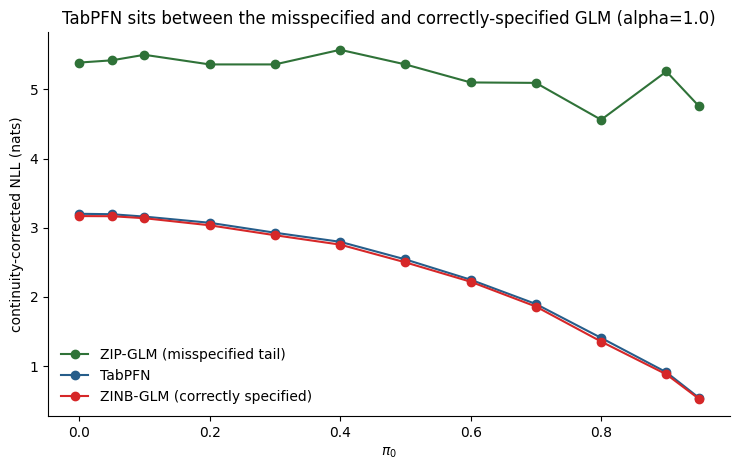

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
sub = zip_df[zip_df["alpha"] == 1.0]
for model, color, label in [("zip_glm", C_ZIP, "ZIP-GLM (misspecified tail)"),
                             ("tabpfn", C_TABPFN, "TabPFN"),
                             ("zinb_glm", C_ZINB, "ZINB-GLM (correctly specified)")]:
    m = sub[sub["model"] == model].groupby("pi0")["cont_nll_mean"].mean()
    ax.plot(m.index, m.values, marker="o", color=color, label=label)
ax.set_xlabel(r"$\pi_0$"); ax.set_ylabel("continuity-corrected NLL (nats)")
ax.set_title("TabPFN sits between the misspecified and correctly-specified GLM (alpha=1.0)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

TabPFN convincingly beats `zip_glm` (the gap we already knew about), but it does **not**
beat `zinb_glm` &mdash; the correctly-specified model keeps a small, real edge throughout at
$\alpha=1.0$. A model that was never told this was a count problem, let alone a zero-inflated
one, lands within a few hundredths of a nat ($+0.015$ to $+0.053$) of a model built with
exactly the right likelihood, while comfortably beating one built with almost the right
likelihood.

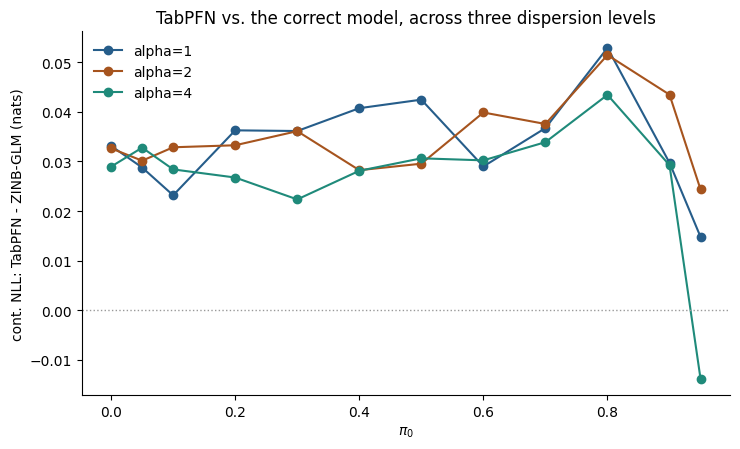

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for alpha, color in ALPHAS:
    s = zip_df[zip_df["alpha"] == alpha]
    piv = s.groupby(["model", "pi0"])["cont_nll_mean"].mean().unstack("model")
    diff = (piv["tabpfn"] - piv["zinb_glm"]).sort_index()
    ax.plot(diff.index, diff.values, marker="o", color=color, label=f"alpha={alpha:g}")
ax.axhline(0, color="#999", linewidth=1, linestyle=":")
ax.set_xlabel(r"$\pi_0$"); ax.set_ylabel("cont. NLL: TabPFN - ZINB-GLM (nats)")
ax.set_title("TabPFN vs. the correct model, across three dispersion levels")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

TabPFN's small deficit against the correct model is essentially flat in both $\pi_0$ and
$\alpha$: $+0.015$ to $+0.053$ nats at $\alpha=1.0$, $+0.024$ to $+0.051$ at $\alpha=2.0$,
and $-0.014$ to $+0.043$ at $\alpha=4.0$ (TabPFN edging ahead only at the extreme,
$\pi_0=0.95$). There is no trend with zero-inflation or dispersion here. (On TabPFN v3, the
$\alpha=1.0$ gap instead grew with $\pi_0$ to $+0.34$ nats &mdash; that was a property of the
older model, not of dispersion.)

## 3. TabPFN vs ZIP-GLM: does the misspecified-model advantage change with dispersion?

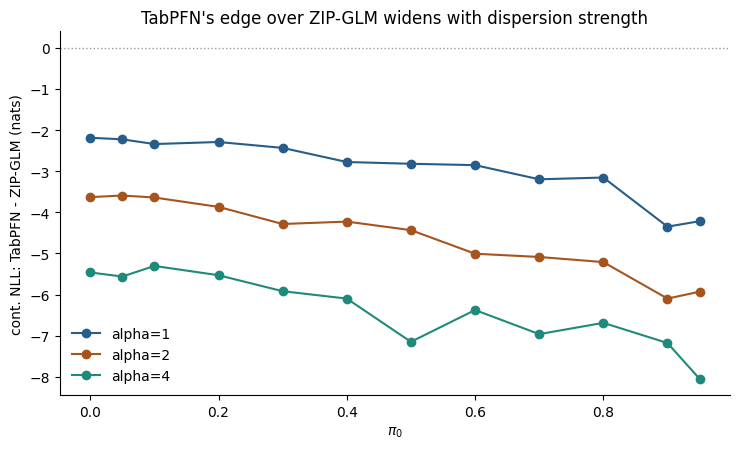

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for alpha, color in ALPHAS:
    sub = zip_df[zip_df["alpha"] == alpha]
    piv = sub.groupby(["model", "pi0"])["cont_nll_mean"].mean().unstack("model")
    diff = (piv["tabpfn"] - piv["zip_glm"]).sort_index()
    ax.plot(diff.index, diff.values, marker="o", color=color, label=f"alpha={alpha:g}")
ax.axhline(0, color="#999", linewidth=1, linestyle=":")
ax.set_xlabel(r"$\pi_0$"); ax.set_ylabel("cont. NLL: TabPFN - ZIP-GLM (nats)")
ax.set_title("TabPFN's edge over ZIP-GLM widens with dispersion strength")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

Unlike the ZINB-GLM comparison, this one *is* a clean, monotonic trend: the gap widens
steadily with $\alpha$ ($-2.2$ to $-4.2$ nats across the $\pi_0$ grid at $\alpha=1.0$;
$-3.6$ to $-5.9$ at $\alpha=2.0$; $-5.5$ to $-8.0$ at $\alpha=4.0$). The more the
Poisson-tailed GLM's variance assumption is wrong, the more it costs, while TabPFN's flexible
histogram keeps adapting without being told the parametric form at all. The contrast with
Section 2 is the point: TabPFN's margin over the *misspecified* model grows steadily with
dispersion, while its deficit against the *correct* model stays small and flat.

## 4. Zero-calibration: both zero-inflation-aware GLMs vs. TabPFN

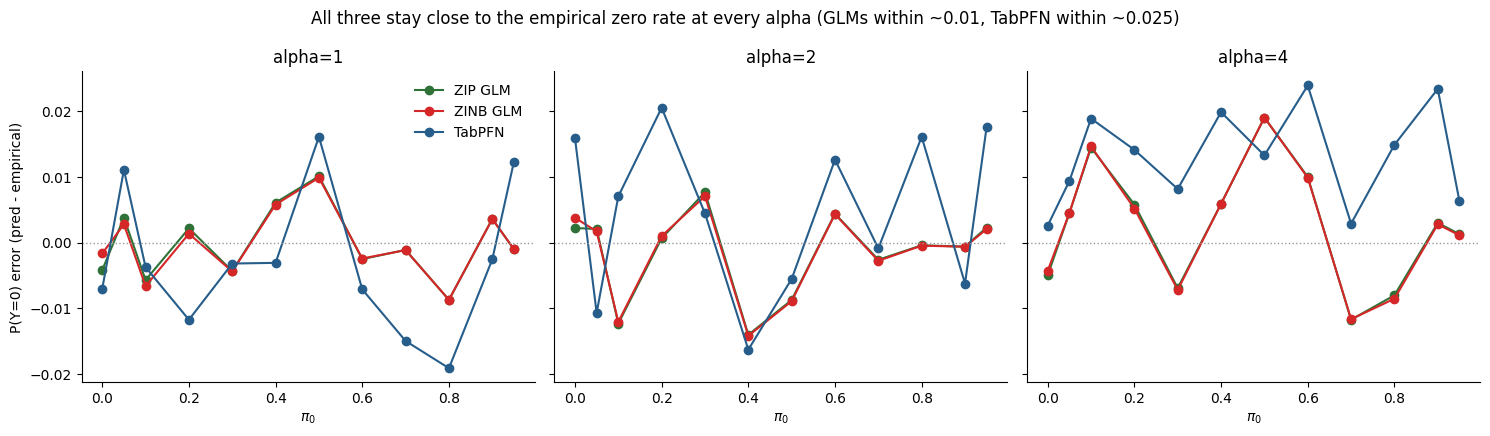

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
for ax, (alpha, color_a) in zip(axes, ALPHAS):
    for model, color in [("zip_glm", C_ZIP), ("zinb_glm", C_ZINB), ("tabpfn", C_TABPFN)]:
        sub = zip_df[(zip_df["alpha"] == alpha) & (zip_df["model"] == model)]
        err = (sub["p_zero_pred_mean"] - sub["p_zero_empirical"]).groupby(sub["pi0"]).mean()
        ax.plot(err.index, err.values, marker="o", color=color, label=MODEL_LABEL[model])
    ax.axhline(0, color="#999", linewidth=1, linestyle=":")
    ax.set_title(f"alpha={alpha:g}")
    ax.set_xlabel(r"$\pi_0$")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("P(Y=0) error (pred - empirical)")
axes[0].legend(frameon=False)
fig.suptitle("All three stay close to the empirical zero rate at every alpha (GLMs within ~0.01, TabPFN within ~0.025)")
fig.tight_layout()
plt.show()

Both zero-inflation-aware GLMs stay within about $\pm0.02$ of perfect calibration at
*all three* dispersion levels ($\pm0.01$ at $\alpha=1.0$) &mdash; the logit component does its
one job regardless of whether the count component's own distributional assumption is wrong
(`zip_glm`) or right (`zinb_glm`). TabPFN is nearly as close, with no systematic pattern:
$-0.019$ to $+0.016$ at $\alpha=1.0$, $-0.016$ to $+0.020$ at $\alpha=2.0$, and $+0.003$ to
$+0.024$ at $\alpha=4.0$. (The mid-grid over-prediction hump peaking at $+0.097$ that v3
showed at $\alpha=1.0$ does not reproduce on v3.5.)

## 5. TabPFN's native-NLL stability

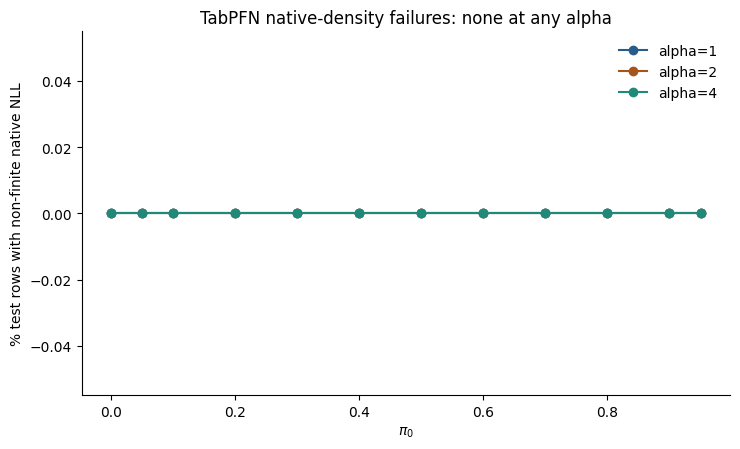

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for alpha, color in ALPHAS:
    sub = zip_df[(zip_df["alpha"] == alpha) & (zip_df["model"] == "tabpfn")]
    frac = sub.groupby("pi0")["native_nll_frac_nonfinite"].mean()
    ax.plot(frac.index, frac.values * 100, marker="o", color=color, label=f"alpha={alpha:g}")
ax.set_xlabel(r"$\pi_0$"); ax.set_ylabel("% test rows with non-finite native NLL")
ax.set_title("TabPFN native-density failures: none at any alpha")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

**No failures at any dispersion level.** TabPFN's native NLL is finite on every one of the
360,000 zip-arm test rows (120 cells &times; 1,000 rows &times; 3 values of $\alpha$). Neither
GLM ever produces a non-finite native NLL either (Section 1) &mdash; though their own failure
mode (a degenerate or wildly extrapolated point prediction) is silent rather than flagged.
(On TabPFN v3, $\alpha=1.0$ had failures on up to 0.75% of rows at $\pi_0\ge0.8$; reading
that as a dispersion effect was wrong &mdash; it was a model-version effect.)

## 6. Does the log1p transform help, and does that change with dispersion?

In [10]:
for alpha, _ in ALPHAS:
    sub = zip_df[zip_df["alpha"] == alpha]
    piv = sub.groupby(["model", "pi0"])["cont_nll_mean"].mean().unstack("model")
    diff = (piv["tabpfn_log1p"] - piv["tabpfn"]).sort_index()
    print(f"alpha={alpha:g}  cont. NLL: TabPFN-log1p - TabPFN (nats, +=worse)")
    print(diff.round(3).to_string())
    print()

alpha=1  cont. NLL: TabPFN-log1p - TabPFN (nats, +=worse)
pi0
0.000    0.014
0.050    0.016
0.100    0.018
0.200   -0.005
0.300   -0.000
0.400    0.013
0.500    0.007
0.600    0.013
0.700    0.025
0.800    0.029
0.900    0.061
0.950    0.001

alpha=2  cont. NLL: TabPFN-log1p - TabPFN (nats, +=worse)
pi0
0.000   -0.005
0.050   -0.003
0.100    0.000
0.200    0.007
0.300    0.004
0.400    0.013
0.500    0.002
0.600   -0.005
0.700    0.009
0.800    0.047
0.900    0.027
0.950   -0.019

alpha=4  cont. NLL: TabPFN-log1p - TabPFN (nats, +=worse)
pi0
0.000    0.004
0.050    0.007
0.100   -0.002
0.200    0.006
0.300    0.005
0.400   -0.002
0.500    0.004
0.600    0.022
0.700    0.062
0.800    0.054
0.900    0.021
0.950   -0.017



The verdict holds across all three levels: the log1p transform never reliably helps. It is
close to a wash through most of each grid, and where it differs it is usually worse:
$-0.005$ to $+0.061$ nats at $\alpha=1.0$ (worse at 10 of 12 $\pi_0$ values), $-0.019$ to
$+0.047$ at $\alpha=2.0$, and $-0.017$ to $+0.062$ at $\alpha=4.0$, with the largest penalties
in the $\pi_0=0.7$&ndash;$0.9$ range. Its point predictions are no better either: its
worst-case RMSE is the highest of the three mean-matched models at $\alpha=1.0$ and $4.0$
(Section 1).

## Conclusions

- **The mean-matching design worked as intended for four of five models, at all three
  dispersion levels.** With $E[Y\mid x]$ identical across arms, RMSE/MAE gaps for
  `poisson_glm`, `zip_glm` (mostly), `tabpfn`, and `tabpfn_log1p` collapsed to the DGP's own
  noise ceiling; every real difference between those models showed up in NLL and
  zero-calibration, exactly where the design intended.

- **ZINB-GLM's small-sample MLE fragility gets worse, not better, as dispersion rises.**
  Its worst-case RMSE climbs from elevated (95.40 at $\alpha=1.0$) to a genuine outlier
  (1308.82 at $\alpha=4.0$, over 10&times; every other model). Two distinct numerical issues
  were found and handled differently: a convergence-to-invalid-dispersion bug (fixed, verified
  at 0% non-finite native NLL everywhere) and a residual mean-regression extrapolation
  instability that isn't invalid, just a genuinely bad point estimate on rare covariate
  combinations (disclosed, not fixed further &mdash; a small-sample statistical limitation, not
  a software bug).

- **Zero-calibration is essentially free of which count-distribution assumption a
  zero-inflation model makes, at every dispersion level tested.** Both `zip_glm` and
  `zinb_glm` track the empirical zero-rate to within about $\pm0.02$ at $\alpha=1.0$, $2.0$,
  and $4.0$, regardless of whether their count component is misspecified or exactly right.
  TabPFN, with no zero-inflation component at all, stays within about $\pm0.025$.

- **TabPFN's honest position is "between," not "best," and that doesn't change with
  dispersion.** It convincingly beats the *misspecified* `zip_glm` on overall density fit, by a
  margin that widens steadily with $\alpha$ ($-2.2$ to $-4.2$, $-3.6$ to $-5.9$, and $-5.5$ to
  $-8.0$ nats across the $\pi_0$ grid). It does not reliably beat the *correctly-specified*
  `zinb_glm`, but the gap is small and flat: $+0.02$ to $+0.05$ nats at almost every $\pi_0$
  and $\alpha$, with TabPFN edging ahead only at $\alpha=4.0$, $\pi_0=0.95$.

- **On TabPFN v3.5, dispersion changes only one of TabPFN's comparisons.** Its margin over
  `zip_glm` grows with $\alpha$; its deficit against `zinb_glm`, its zero-calibration and its
  density robustness (no non-finite values) all stay the same across $\alpha=1.0$, $2.0$ and
  $4.0$. The $\alpha=1.0$-specific zero-calibration hump, native-NLL failures and growing gap
  to `zinb_glm` seen in the first run were all properties of TabPFN v3, and disappeared when
  $\alpha=1.0$ was re-scored on v3.5.

- **The numerical failure modes here belong to the GLMs, not TabPFN.** `zip_glm`'s Hessian
  overflows mainly at $\alpha=2.0$. `zinb_glm` needed two separate optimizer fixes for a
  convergence failure, plus carries a residual mean-estimation instability that gets worse
  (not better) as $\alpha$ climbs &mdash; the most persistent failure mode in the study. On
  v3.5, TabPFN's density is finite everywhere; its only numerical care point is
  `tabpfn_log1p`'s back-transformed mean (see Caveats). Being "correctly specified" bought
  `zinb_glm` the best density fit when it converges cleanly, not the most robust optimizer.

- **Caveats.** One synthetic DGP, three dispersion levels ($\alpha=1.0$, $2.0$, $4.0$; not a
  dense sweep), 10 seeds each, a single fixed $\pi_0$ grid, five models. TabPFN results are
  specific to `v3.5_default`: v3 behaved differently at $\alpha=1.0$, so re-test before
  carrying these findings to another model version. Three numerical fixes were needed to make
  the comparison trustworthy at all: `TabPFNLog1pModel.mean()` clips Monte-Carlo draws to
  $10\times$ the largest training count; `ZinbGLM.fit()` retries from an explicit starting
  point, then switches optimizer entirely, when the default fails to converge. Even after all
  three, `zinb_glm`'s baseline-arm fit (used only as the dashed reference line in plots, not
  part of the $\pi_0$-grid analysis) and its $\alpha=4.0$ worst-case RMSE remain genuinely
  poor &mdash; disclosed statistical limitations of a small-sample MLE under exactly the
  conditions this DGP was designed to stress, not bugs left unfixed.